# 04 · Weights as Probability Distributions

*Companion notebook for the chapter sections* **Weights as Probability Distributions · Representing the Weight Mathematically**

There is one model where the Bayesian posterior over weights can be computed **exactly**: a linear model with Gaussian prior and Gaussian noise.
It is also exactly a **one-hidden-layer network whose hidden layer is frozen and whose output layer is Bayesian**. Studying it shows what a BNN is trying to compute.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

## 1. Representing a weight as a distribution

A traditional weight is one number, e.g. $w=0.73$. A Bayesian weight is a random variable, e.g.

$$w\sim\mathcal N(\mu,\sigma^2),$$

described by a **mean** (best guess) and a **standard deviation** (how unsure we are). For a whole network, $\mathbf w\sim p(\mathbf w)$ before seeing data (the **prior**) and $\mathbf w\sim p(\mathbf w\mid\mathcal D)$ after (the **posterior**).

Every draw of $\mathbf w$ is a different network, so a distribution over weights is a **distribution over functions**.

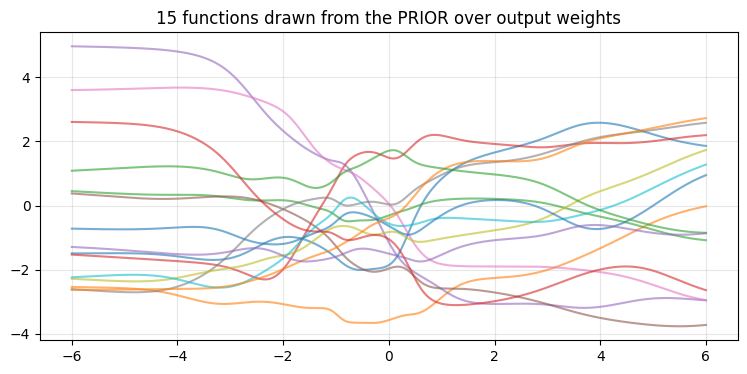

In [2]:
# a "network" with a fixed random tanh hidden layer (40 units) and a Bayesian output layer
H = 40
W_hidden = rng.normal(0, 2.0, H); b_hidden = rng.uniform(-6, 6, H)
def features(x):
    return np.tanh(np.outer(x, W_hidden) + b_hidden)          # shape (n, H)

xg = np.linspace(-6, 6, 400); Fg = features(xg)
alpha = 10.0                                                 # prior precision: w ~ N(0, alpha^-1 I)

for _ in range(15):
    w = rng.normal(0, 1 / np.sqrt(alpha), H)
    plt.plot(xg, Fg @ w, alpha=0.6)
plt.title("15 functions drawn from the PRIOR over output weights"); plt.show()

## 2. The exact posterior

With prior $p(\mathbf w)=\mathcal N(\mathbf 0,\alpha^{-1}I)$ and likelihood $p(\mathbf y\mid\mathbf w)=\mathcal N(\Phi\mathbf w,\beta^{-1}I)$ (noise precision $\beta=1/\sigma^2$), the posterior is Gaussian:

$$p(\mathbf w\mid\mathcal D)=\mathcal N(\mathbf m_N,S_N),\qquad
S_N=\big(\alpha I+\beta\,\Phi^\top\Phi\big)^{-1},\qquad
\mathbf m_N=\beta\,S_N\Phi^\top\mathbf y.$$

Note that $\mathbf m_N$ is exactly the MAP solution of notebook 03 — the Bayesian answer adds the covariance $S_N$.

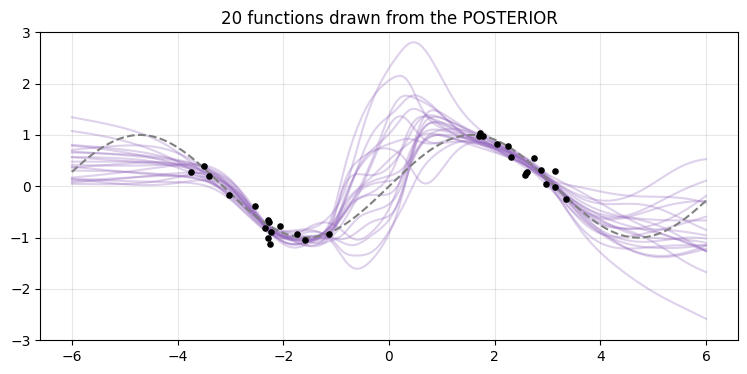

In [3]:
sigma = 0.15; beta = 1 / sigma**2
x = np.concatenate([rng.uniform(-4, -1, 15), rng.uniform(1.5, 3.5, 15)])
y = np.sin(x) + sigma * rng.standard_normal(len(x))
F = features(x)

S_N = np.linalg.inv(alpha * np.eye(H) + beta * F.T @ F)
m_N = beta * S_N @ F.T @ y

for _ in range(20):
    w = rng.multivariate_normal(m_N, S_N)
    plt.plot(xg, Fg @ w, c="C4", alpha=0.3)
plt.scatter(x, y, c="k", s=14, zorder=3)
plt.plot(xg, np.sin(xg), "--", c="gray")
plt.ylim(-3, 3); plt.title("20 functions drawn from the POSTERIOR"); plt.show()

## 3. The posterior predictive and its two parts

For a new input $x^*$ with features $\boldsymbol\phi^*$:

$$p(y^*\mid x^*,\mathcal D)=\mathcal N\!\Big(\mathbf m_N^\top\boldsymbol\phi^*,\;
\underbrace{\beta^{-1}}_{\text{aleatoric}}+\underbrace{\boldsymbol\phi^{*\top}S_N\boldsymbol\phi^*}_{\text{epistemic}}\Big)$$

This is the variance decomposition from notebook 00, now computed exactly.

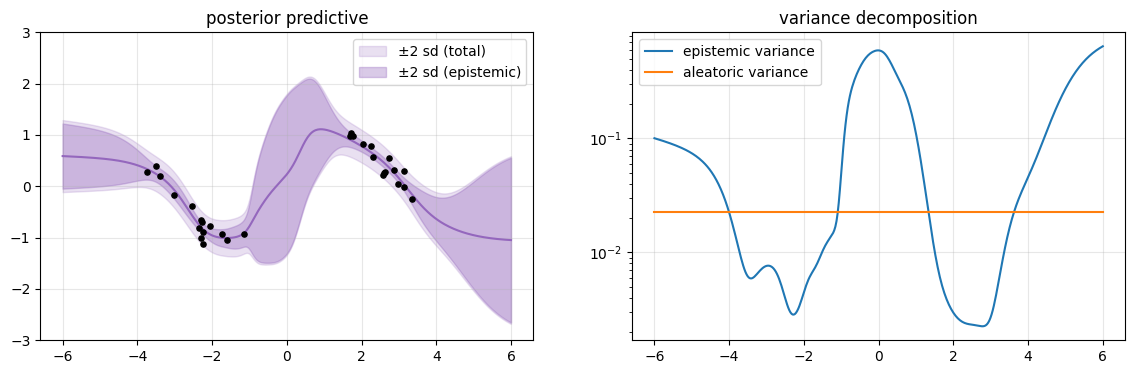

In [4]:
mean = Fg @ m_N
epi = np.einsum("ij,jk,ik->i", Fg, S_N, Fg)
alea = np.full_like(epi, 1 / beta)
total_sd = np.sqrt(epi + alea)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].fill_between(xg, mean - 2 * total_sd, mean + 2 * total_sd, color="C4", alpha=0.2, label="±2 sd (total)")
ax[0].fill_between(xg, mean - 2 * np.sqrt(epi), mean + 2 * np.sqrt(epi), color="C4", alpha=0.35, label="±2 sd (epistemic)")
ax[0].plot(xg, mean, c="C4"); ax[0].scatter(x, y, c="k", s=14, zorder=3)
ax[0].set_ylim(-3, 3); ax[0].legend(); ax[0].set_title("posterior predictive")
ax[1].plot(xg, epi, label="epistemic variance"); ax[1].plot(xg, alea, label="aleatoric variance")
ax[1].set_yscale("log"); ax[1].legend(); ax[1].set_title("variance decomposition")
plt.show()

## 4. Learning = the posterior shrinking

Watch the posterior predictive tighten as points arrive one batch at a time.

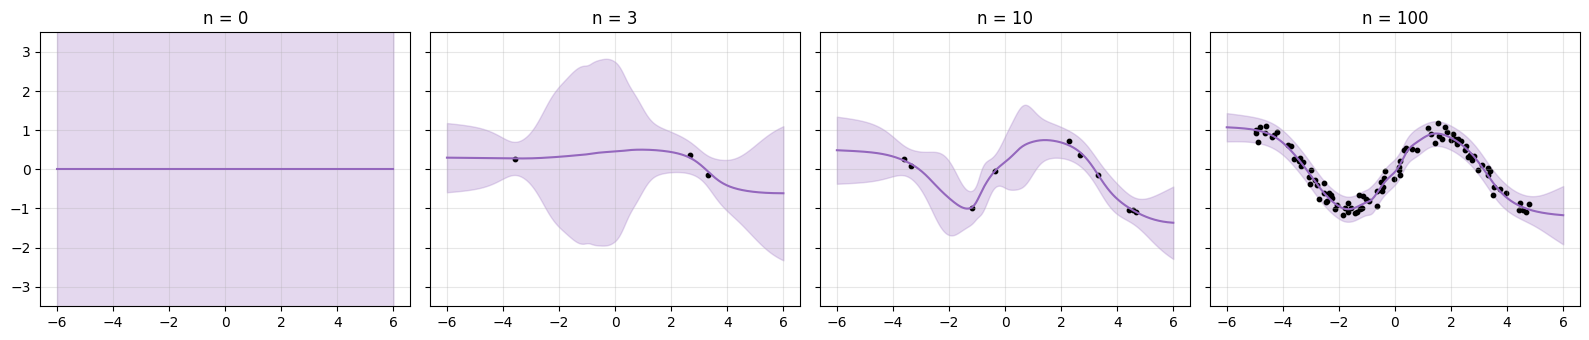

In [5]:
x_all = rng.uniform(-5, 5, 100); y_all = np.sin(x_all) + sigma * rng.standard_normal(100)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, n in zip(axes, [0, 3, 10, 100]):
    Fn = features(x_all[:n])
    S = np.linalg.inv(alpha * np.eye(H) + beta * Fn.T @ Fn)
    m = beta * S @ Fn.T @ y_all[:n]
    mu = Fg @ m; sd = np.sqrt(np.einsum("ij,jk,ik->i", Fg, S, Fg) + 1 / beta)
    ax.fill_between(xg, mu - 2 * sd, mu + 2 * sd, color="C4", alpha=0.25); ax.plot(xg, mu, c="C4")
    ax.scatter(x_all[:n], y_all[:n], c="k", s=10); ax.set_title(f"n = {n}"); ax.set_ylim(-3.5, 3.5)
plt.tight_layout(); plt.show()

## 5. From here to a real BNN

In a real BNN **all** layers are Bayesian and the network is nonlinear in its weights. Then:

* the posterior $p(\mathbf w\mid\mathcal D)$ is **not Gaussian** and can have many modes,
* the normalising integral $p(\mathcal D)=\int p(\mathcal D\mid\mathbf w)p(\mathbf w)\,d\mathbf w$ has **no closed form**.

So we approximate. The main families (see *Approximations for Estimation*):

| method | idea | notebook |
|---|---|---|
| MCMC | draw samples from the posterior with a Markov chain | 05 |
| Variational inference (Bayes by Backprop) | fit a simple distribution $q(\mathbf w)$ close to the posterior | 06, 08 |
| MC dropout | dropout at test time ≈ approximate VI (Gal, 2016) | 07 |
| Deep ensembles | several MAP solutions as rough posterior samples | 07 |
| Laplace approximation | a Gaussian around the MAP, using curvature | exercise |

## Exercises
1. Change the prior precision `alpha` to 0.01 and 100. What happens to the prior samples and to the predictive band?
2. Implement the **Laplace approximation** for this model. Why is it exact here?
3. The *evidence* $p(\mathbf y)=\mathcal N(\mathbf 0,\alpha^{-1}\Phi\Phi^\top+\beta^{-1}I)$ is also available in closed form. Use it to choose `alpha` automatically.